# Gráficas 1: Cómputo de PI
En este notebook crearemos las gráficas y tablas pertinentes para la realización de este TFG. 

In [1]:
R002_SEC_CSV = "/home/usc/cursos/curso1285/home/TFG/problemas/Problema_002/results/P_002_sec.csv"
R002_OMP_CSV = "/home/usc/cursos/curso1285/home/TFG/problemas/Problema_002/results/P_002_omp.csv"
R002_ESP_1_CSV = "/home/usc/cursos/curso1285/home/TFG/problemas/Problema_002/results/P_002_esp_1.csv"
R002_ESP_2_CSV = "/home/usc/cursos/curso1285/home/TFG/problemas/Problema_002/results/P_002_esp_2.csv"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

sec = pd.read_csv(R002_SEC_CSV)
omp = pd.read_csv(R002_OMP_CSV)
esp1 = pd.read_csv(R002_ESP_1_CSV)
esp2 = pd.read_csv(R002_ESP_2_CSV)

/mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/lib/python3.7/site-packages/ipykernel_launcher.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
/mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/lib/python3.7/site-packages/ipykernel_launcher.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


139     3.722884
144     5.570251
149     7.337349
154    11.678423
Name: speedup, dtype: float64


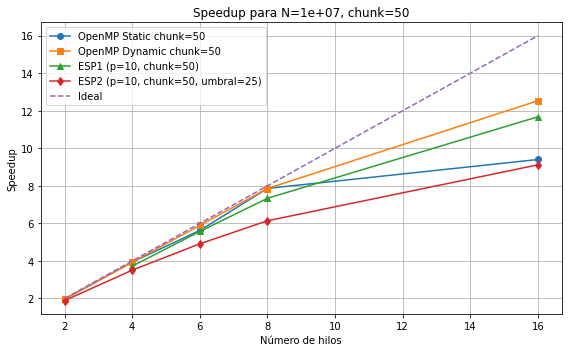

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros a comparar
N = 1e7
p = 10
chunk = 50
umbral = 25

# Tiempo secuencial
t_sec = sec.loc[sec["N"] == N, "TIME_mean"].iloc[0]

# Filtrar
omp_N = omp[omp["N"] == N].copy()

esp1_N = esp1[
    (esp1["N"] == N) &
    (esp1["p"] == p) &
    (esp1["chunk"] == chunk)
].copy()

esp2_N = esp2[
    (esp2["N"] == N) &
    (esp2["p"] == p) &
    (esp2["chunk"] == chunk) &
    (esp2["umbral"] == umbral)
].copy()

# Speedups
omp_N["speedup"] = t_sec / omp_N["TIME_mean"]
esp1_N["speedup"] = t_sec / esp1_N["TIME_mean"]
esp2_N["speedup"] = t_sec / esp2_N["TIME_mean"]

plt.figure(figsize=(8,5))

# OpenMP Static
static = omp_N[omp_N["sched"] == "static"][omp_N["chunk"] == chunk]
plt.plot(
    static["T"],
    static["speedup"],
    marker="o",
    label=f"OpenMP Static chunk={chunk}"
)

# OpenMP Dynamic
dynamic = omp_N[omp_N["sched"] == "dynamic"][omp_N["chunk"] == chunk]
plt.plot(
    dynamic["T"],
    dynamic["speedup"],
    marker="s",
    label=f"OpenMP Dynamic chunk={chunk}"
)

# ESP1
plt.plot(
    esp1_N["T"],
    esp1_N["speedup"],
    marker="^",
    label=f"ESP1 (p={p}, chunk={chunk})"
)

print(esp1_N["speedup"])
# ESP2
plt.plot(
    esp2_N["T"],
    esp2_N["speedup"],
    marker="d",
    label=f"ESP2 (p={p}, chunk={chunk}, umbral={umbral})"
)

# Speedup ideal
hilos = sorted(
    set(omp_N["T"]) |
    set(esp1_N["T"]) |
    set(esp2_N["T"])
)

plt.plot(
    hilos,
    hilos,
    '--',
    label="Ideal"
)

plt.xlabel("Número de hilos")
plt.ylabel("Speedup")
plt.title(f"Speedup para N={N:.0e}, chunk={chunk}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

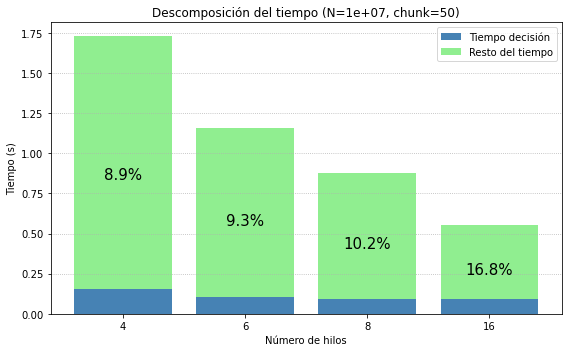

In [15]:
import matplotlib.pyplot as plt
import numpy as np

N = 1e7
chunk = 50

valid_threads = [1, 2, 4, 6, 8, 16]

df = esp1[
    (esp1["N"] == N) &
    (esp1["chunk"] == chunk) &
    (esp1["T"].isin(valid_threads))
].copy()

df = df.sort_values("T")

x = np.arange(len(df))

total = df["TIME_mean"].values
decision = df["TIME_dec_mean"].values
resto = total - decision
pct_dec = (decision / total) * 100

plt.figure(figsize=(8,5))

plt.bar(x, decision, color="steelblue", label="Tiempo decisión")
plt.bar(x, resto, bottom=decision, color="lightgreen", label="Resto del tiempo")

for i in range(len(x)):
    plt.text(
        x[i],
        total[i] * 0.5,
        f"{pct_dec[i]:.1f}%",
        ha="center",
        va="center",
        fontsize=15,
    )

plt.xticks(x, df["T"]) 
plt.xlabel("Número de hilos")
plt.ylabel("Tiempo (s)")
plt.title(f"Descomposición del tiempo (N={N:.0e}, chunk={chunk})")
plt.legend()
plt.grid(axis="y", linestyle=":")
plt.tight_layout()
plt.show()

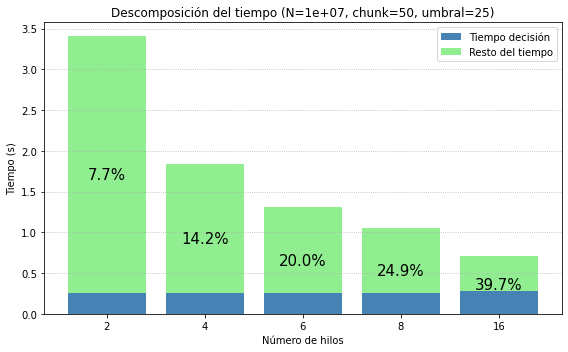

In [17]:
import matplotlib.pyplot as plt
import numpy as np

N = 1e7
chunk = 50
umbral = 25

valid_threads = [1, 2, 4, 6, 8, 16]

df = esp2[
    (esp2["N"] == N) &
    (esp2["chunk"] == chunk) &
    (esp2["T"].isin(valid_threads)) &
    (esp2["umbral"] == umbral)
].copy()

df = df.sort_values("T")

x = np.arange(len(df))

total = df["TIME_mean"].values
decision = df["TIME_dec_mean"].values
resto = total - decision
pct_dec = (decision / total) * 100

plt.figure(figsize=(8,5))

plt.bar(x, decision, color="steelblue", label="Tiempo decisión")
plt.bar(x, resto, bottom=decision, color="lightgreen", label="Resto del tiempo")

for i in range(len(x)):
    plt.text(
        x[i],
        total[i] * 0.5,
        f"{pct_dec[i]:.1f}%",
        ha="center",
        va="center",
        fontsize=15,
    )

plt.xticks(x, df["T"]) 
plt.xlabel("Número de hilos")
plt.ylabel("Tiempo (s)")
plt.title(f"Descomposición del tiempo (N={N:.0e}, chunk={chunk}, umbral={umbral})")
plt.legend()
plt.grid(axis="y", linestyle=":")
plt.tight_layout()
plt.show()

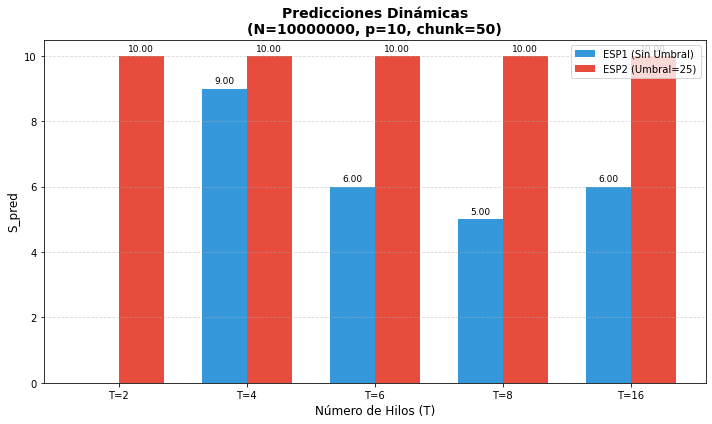

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar tus datos (reemplaza con la ruta real de tus archivos)
# esp1 = pd.read_csv("esp1.csv")
# esp2 = pd.read_csv("esp2.csv")

# ---------------------------------------------------------
# Configuración concreta que deseas buscar
# ---------------------------------------------------------
N_buscado = int(1e7)  # Aseguramos entero para evitar fallos de tipo
p_buscado = 10
chunk_buscado = 50
umbral_buscado = 25

# ---------------------------------------------------------
# Filtrado de datos
# ---------------------------------------------------------
filt_esp1 = esp1[
    (esp1["N"] == N_buscado) & 
    (esp1["p"] == p_buscado) & 
    (esp1["chunk"] == chunk_buscado)
].sort_values(by="T")

filt_esp2 = esp2[
    (esp2["N"] == N_buscado) & 
    (esp2["p"] == p_buscado) & 
    (esp2["chunk"] == chunk_buscado) & 
    (esp2["umbral"] == umbral_buscado)
].sort_values(by="T")

# ---------------------------------------------------------
# Alineación y preparación del gráfico de barras agrupadas
# ---------------------------------------------------------
# Conseguimos todos los valores de T únicos que aparezcan en ambos
todos_los_T = sorted(list(set(filt_esp1["T"]).union(set(filt_esp2["T"]))))


# Mapeamos los valores de S_pred asegurando que coincidan con su T correspondiente
s_pred_esp1 = [
    10 - filt_esp1[filt_esp1["T"] == t]["S_pred"].values[0]
    if t in filt_esp1["T"].values else 0
    for t in todos_los_T
]

s_pred_esp2 = [
    10 - filt_esp2[filt_esp2["T"] == t]["S_pred"].values[0]
    if t in filt_esp2["T"].values else 0
    for t in todos_los_T
]

# Posiciones de las barras
x = np.arange(len(todos_los_T))
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Renderizar barras emparejadas para comparar ESP1 vs ESP2
rects1 = ax.bar(x - width/2, s_pred_esp1, width, label='ESP1 (Sin Umbral)', color='#3498db')
rects2 = ax.bar(x + width/2, s_pred_esp2, width, label=f'ESP2 (Umbral={umbral_buscado})', color='#e74c3c')

# Configuración de etiquetas y diseño
ax.set_ylabel('S_pred', fontsize=12)
ax.set_xlabel('Número de Hilos (T)', fontsize=12)
ax.set_title(f'Predicciones Dinámicas\n(N={N_buscado}, p={p_buscado}, chunk={chunk_buscado})', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"T={t}" for t in todos_los_T])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir los valores numéricos encima de cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0: # Evita etiquetar valores que no existan
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # Desplazamiento vertical de 3 puntos
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

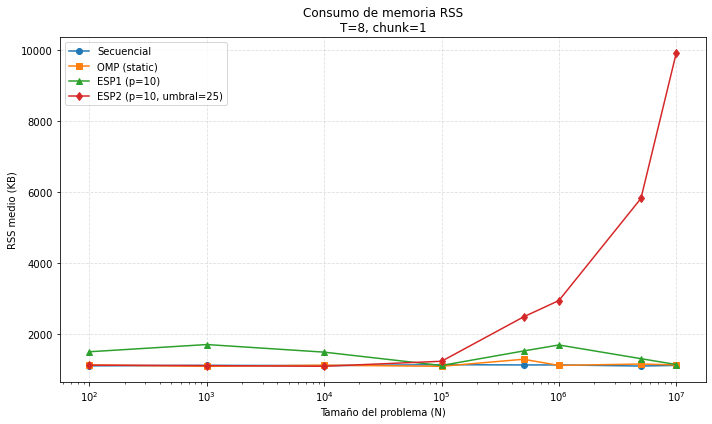

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# Parámetros de comparación
# --------------------------
T = 8
p = 10
chunk = 1
umbral = 25
sched = "static"

# --------------------------
# Filtrado
# --------------------------
omp_f = omp[
    (omp["T"] == T) &
    (omp["sched"] == sched) &
    (omp["chunk"] == chunk)
].sort_values("N")

esp1_f = esp1[
    (esp1["T"] == T) &
    (esp1["p"] == p) &
    (esp1["chunk"] == chunk)
].sort_values("N")

esp2_f = esp2[
    (esp2["T"] == T) &
    (esp2["p"] == p) &
    (esp2["chunk"] == chunk) &
    (esp2["umbral"] == umbral)
].sort_values("N")

sec_f = sec.sort_values("N")

# --------------------------
# Gráfica
# --------------------------
plt.figure(figsize=(10,6))

plt.plot(
    sec_f["N"],
    sec_f["RSS_mean"],
    marker="o",
    label="Secuencial"
)

plt.plot(
    omp_f["N"],
    omp_f["RSS_mean"],
    marker="s",
    label=f"OMP ({sched})"
)

plt.plot(
    esp1_f["N"],
    esp1_f["RSS_mean"],
    marker="^",
    label=f"ESP1 (p={p})"
)

plt.plot(
    esp2_f["N"],
    esp2_f["RSS_mean"],
    marker="d",
    label=f"ESP2 (p={p}, umbral={umbral})"
)

plt.xlabel("Tamaño del problema (N)")
plt.ylabel("RSS medio (KB)")
plt.title(
    f"Consumo de memoria RSS\nT={T}, chunk={chunk}"
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

# Muy útil cuando N toma valores 10³,10⁴,10⁵,...
plt.xscale("log")

plt.tight_layout()
plt.show()

In [112]:
# ---------------------------------------------------------
# SCRIPT DE DIAGNÓSTICO
# ---------------------------------------------------------
print("=== DIAGNÓSTICO DE DATOS ===")

# 1. Verificar si los DataFrames tienen filas
print(f"Total filas en esp1: {len(esp1)}")
print(f"Total filas en esp2: {len(esp2)}")

# 2. Ver los valores únicos de cada columna para entender qué hay dentro
print("\nValores disponibles en 'esp1':")
print(f"-> N: {esp1['N'].unique() if 'N' in esp1 else '¡No existe la columna N!'}")
print(f"-> p: {esp1['p'].unique() if 'p' in esp1 else '¡No existe la columna p!'}")
print(f"-> chunk: {esp1['chunk'].unique() if 'chunk' in esp1 else '¡No existe la columna chunk!'}")

print("\nValores disponibles en 'esp2':")
print(f"-> N: {esp2['N'].unique() if 'N' in esp2 else '¡No existe la columna N!'}")
print(f"-> p: {esp2['p'].unique() if 'p' in esp2 else '¡No existe la columna p!'}")
print(f"-> chunk: {esp2['chunk'].unique() if 'chunk' in esp2 else '¡No existe la columna chunk!'}")
print(f"-> umbral: {esp2['umbral'].unique() if 'umbral' in esp2 else '¡No existe la columna umbral!'}")

=== DIAGNÓSTICO DE DATOS ===
Total filas en esp1: 4
Total filas en esp2: 0

Valores disponibles en 'esp1':
-> N: [200000000]
-> p: [10]
-> chunk: [ 0  4 10 50]

Valores disponibles en 'esp2':
-> N: []
-> p: []
-> chunk: []
-> umbral: []


Podemos utilizar esta gráfica para demostrar qué planificación debería ser la ganadora en las especulaciones.
Igual podemos mostrarla en barplot.

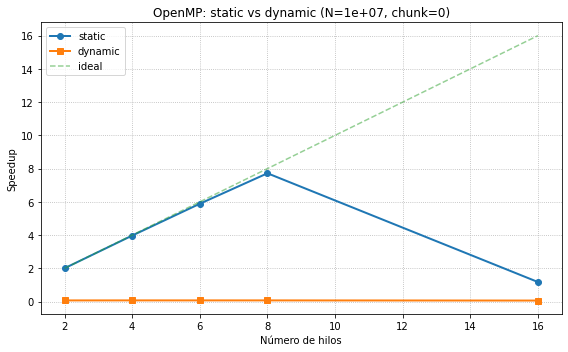

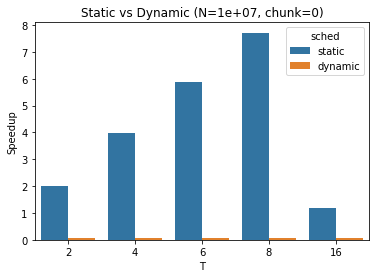

In [6]:
import matplotlib.pyplot as plt

N = 1e7

# Tiempo secuencial
t_sec = sec.loc[sec["N"] == N, "TIME_mean"].iloc[0]

# Filtrar OpenMP para N y chunk deseados
omp_f = omp[
    (omp["N"] == N) &
    (omp["chunk"] == 0)
].copy()

# Calcular speedup
omp_f["speedup"] = t_sec / omp_f["TIME_mean"]

# Separar políticas
static = omp_f[omp_f["sched"] == "static"].sort_values("T")
dynamic = omp_f[omp_f["sched"] == "dynamic"].sort_values("T")

plt.figure(figsize=(8, 5))

plt.plot(
    static["T"],
    static["speedup"],
    marker="o",
    linewidth=2,
    label="static"
)

plt.plot(
    dynamic["T"],
    dynamic["speedup"],
    marker="s",
    linewidth=2,
    label="dynamic"
)

# Speedup ideal
hilos = sorted(omp_f["T"].unique())
plt.plot(
    hilos,
    hilos,
    "--",
    alpha=0.5,
    label="ideal"
)

plt.xlabel("Número de hilos")
plt.ylabel("Speedup")
plt.title(f"OpenMP: static vs dynamic (N={N:.0e}, chunk=0)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

#####################################################################################

import seaborn as sns

omp_f = omp[
    (omp["N"] == N) &
    (omp["chunk"] == 0)
].copy()

omp_f["speedup"] = t_sec / omp_f["TIME_mean"]

sns.barplot(
    data=omp_f,
    x="T",
    y="speedup",
    hue="sched"
)

plt.ylabel("Speedup")
plt.title(f"Static vs Dynamic (N={N:.0e}, chunk=0)")
plt.show()

Aquí hacemos igual que antes pero mostramos que el tamaño de chunk beneficía a ciertas planificaciones.

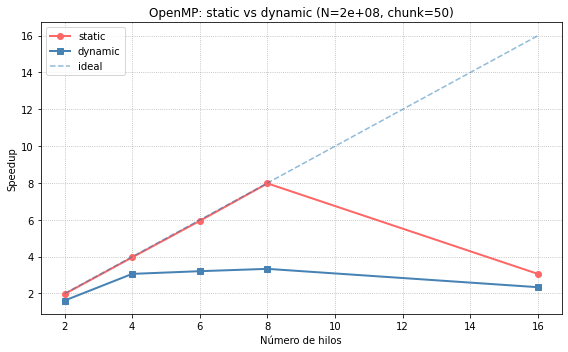

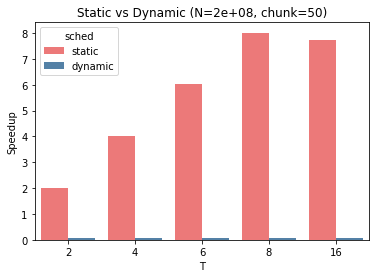

In [10]:
import matplotlib.pyplot as plt

N = 2e8
chunk = 50

# Tiempo secuencial
t_sec = sec.loc[sec["N"] == N, "TIME_mean"].iloc[0]

# Filtrar OpenMP para N y chunk deseados
omp_f = omp[
    (omp["N"] == N) &
    (omp["chunk"] == chunk)
].copy()

# Calcular speedup
omp_f["speedup"] = t_sec / omp_f["TIME_mean"]

omp_f["speedup_std"] = (t_sec / (omp_f["TIME_mean"]**2)) * omp_f["TIME_std"]

# Separar políticas
static = omp_f[omp_f["sched"] == "static"].sort_values("T")
dynamic = omp_f[omp_f["sched"] == "dynamic"].sort_values("T")

plt.figure(figsize=(8, 5))

plt.plot(
    static["T"],
    static["speedup"],
    marker="o",
    linewidth=2,
    label="static",
    color = "#ff6666"
)

plt.plot(
    dynamic["T"],
    dynamic["speedup"],
    marker="s",
    linewidth=2,
    label="dynamic",
    color = "steelblue"
)

# Speedup ideal
hilos = sorted(omp_f["T"].unique())
plt.plot(
    hilos,
    hilos,
    "--",
    alpha=0.5,
    label="ideal",
)

plt.xlabel("Número de hilos")
plt.ylabel("Speedup")
plt.title(f"OpenMP: static vs dynamic (N={N:.0e}, chunk={chunk})")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

#####################################################################################

import seaborn as sns

omp_f = omp[
    (omp["N"] == N) &
    (omp["chunk"] == 0)
].copy()

omp_f["speedup"] = t_sec / omp_f["TIME_mean"]

sns.barplot(
    data=omp_f,
    x="T",
    y="speedup",
    hue="sched",
    palette={
        "static": "#ff6666",
        "dynamic": "steelblue"
    }
)

plt.ylabel("Speedup")
plt.title(f"Static vs Dynamic (N={N:.0e}, chunk=50)")
plt.show()



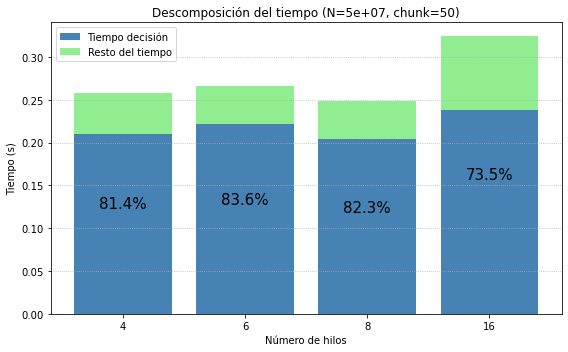

In [69]:
import matplotlib.pyplot as plt
import numpy as np

N = 5e7
chunk = 50

valid_threads = [1, 2, 4, 6, 8, 16]

df = esp1[
    (esp1["N"] == N) &
    (esp1["chunk"] == chunk) &
    (esp1["T"].isin(valid_threads))
].copy()

df = df.sort_values("T")

x = np.arange(len(df))

total = df["TIME_mean"].values
decision = df["TIME_dec_mean"].values
resto = total - decision
pct_dec = (decision / total) * 100

plt.figure(figsize=(8,5))

plt.bar(x, decision, color="steelblue", label="Tiempo decisión")
plt.bar(x, resto, bottom=decision, color="lightgreen", label="Resto del tiempo")

for i in range(len(x)):
    plt.text(
        x[i],
        total[i] * 0.5,
        f"{pct_dec[i]:.1f}%",
        ha="center",
        va="center",
        fontsize=15,
    )

plt.xticks(x, df["T"]) 
plt.xlabel("Número de hilos")
plt.ylabel("Tiempo (s)")
plt.title(f"Descomposición del tiempo (N={N:.0e}, chunk={chunk})")
plt.legend()
plt.grid(axis="y", linestyle=":")
plt.tight_layout()
plt.show()

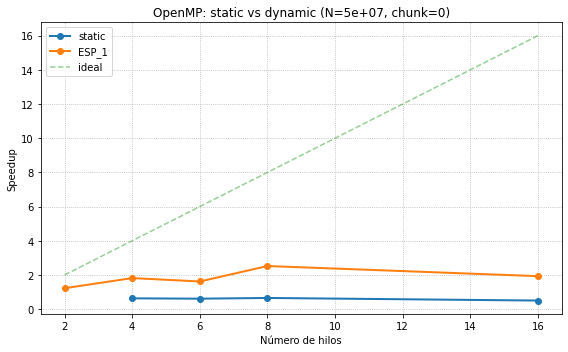

In [6]:
import matplotlib.pyplot as plt

N = 5e7
chunk = 50
umbral = 25

# Tiempo secuencial
t_sec = sec.loc[sec["N"] == N, "TIME_mean"].iloc[0]

# Filtrar OpenMP para N y chunk deseados
esp1_f = esp1[
    (esp1["N"] == N) &
    (esp1["chunk"] == chunk)
].copy()

# Calcular speedup
esp1_f["speedup"] = t_sec / esp1_f["TIME_mean"]

esp2_f = esp2[
    (esp2["N"] == N) &
    (esp2["chunk"] == chunk) &
    (esp2["umbral"] == umbral)
].copy()

esp2_f["speedup"] = t_sec / esp2_f["TIME_mean"]



plt.figure(figsize=(8, 5))

plt.plot(
    esp1_f["T"],
    esp1_f["speedup"],
    marker="o",
    linewidth=2,
    label="static"
)

plt.plot(
    esp2_f["T"],
    esp2_f["speedup"],
    marker="o",
    linewidth=2,
    label="ESP_1"
)
# Speedup ideal
hilos = sorted(omp_f["T"].unique())
plt.plot(
    hilos,
    hilos,
    "--",
    alpha=0.5,
    label="ideal"
)

plt.xlabel("Número de hilos")
plt.ylabel("Speedup")
plt.title(f"OpenMP: static vs dynamic (N={N:.0e}, chunk=0)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()